In [1]:
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import col, count, sum as _sum, when, row_number, desc, to_timestamp
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
import math
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.miscmodels.ordinal_model import OrderedModel
import matplotlib.patches as mpatches

In [2]:
spark = SparkSession.builder.appName("TER").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/17 00:37:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df = spark.read.option("delimiter", "\t").csv(
    '/kaggle/input/open-food-facts/en.openfoodfacts.org.products.csv',
    header=True
)

In [4]:
# Calculer le nombre total de lignes
total_rows = df.count()

In [5]:
from pyspark.sql import functions as F
total_cells = total_rows * len(df.columns)

missing_cells = df.select([
    F.sum(F.col(c).isNull().cast("int")) for c in df.columns
]).toPandas().sum().sum()

print(f"Données manquantes : {missing_cells / total_cells * 100:.2f}%")

26/04/17 00:38:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Données manquantes : 78.61%


In [6]:
threshold = 0.75

# Calculer le ratio de nulls pour chaque colonne
null_ratios = df.select([
    (_sum(when(
        col(c).isNull() | (col(c) == "") | (col(c) == "null"), 
        1
    ).otherwise(0)) / total_rows).alias(c) 
    for c in df.columns
]).first()

# Colonnes à garder (< 75% de nulls)
columns_to_keep = [c for c in df.columns if null_ratios[c] < threshold]

df_cleaned = df.select(columns_to_keep)

print(f"Conservées: {len(columns_to_keep)}/{len(df.columns)}")

Conservées: 69/215


In [7]:
window = Window.partitionBy("code").orderBy(
    desc(to_timestamp("last_modified_datetime"))
)

df_cleaned = df_cleaned.withColumn("row_num", row_number().over(window)) \
                       .filter(col("row_num") == 1) \
                       .drop("row_num")

In [8]:
window = Window.partitionBy("product_name", "brands").orderBy(desc(to_timestamp("last_modified_datetime")))

df_cleaned = (df_cleaned
    .withColumn("row_num", row_number().over(window))
    .filter(
        (col("row_num") == 1) |
        (col("product_name").isNull() & col("brands").isNull())
    )
    .drop("row_num")
)

In [9]:
df_cleaned = df_cleaned.drop("url", "creator", "created_t", "created_datetime", "last_modified_t", "last_modified_by", "last_updated_t", "last_updated_datetime", "brands", "brands_tags", "categories", "categories_tags", 'labels', 'labels_tags', 'countries', 'countries_tags', 'labels', 'labels_tags', 'countries', 'countries_tags:', 'food_groups', 'food_groups_tags', 'states', 'states_tags', 'last_image_t', 'last_image_datetime', 'main_category', 'image_url', 'image_small_url', 'image_ingredients_url', 'image_ingredients_small_url', 'image_nutrition_url', 'image_nutrition_small_url','ingredients_text','nutrition-score-fr_100g')

In [10]:
output_dir = "/kaggle/working/output_temp"

df_cleaned.coalesce(1).write \
    .option("header", "true") \
    .option("sep", "\t") \
    .option("quote", "") \
    .option("escape", "\\") \
    .mode("overwrite") \
    .csv(output_dir)

csv_file = [f for f in os.listdir(output_dir) if f.startswith("part-")][0]
shutil.move(f"{output_dir}/{csv_file}", "/kaggle/working/df.csv")
shutil.rmtree(output_dir)

In [11]:
df = pd.read_csv("/kaggle/working/df.csv", sep='\t', on_bad_lines='skip')

/tmp/ipykernel_23/2633857221.py:1: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/working/df.csv", sep='\t', on_bad_lines='skip')


In [12]:
df.head()

,code,last_modified_datetime,product_name,quantity,brands_en,categories_en,labels_en,countries_en,ingredients_tags,ingredients_analysis_tags,...,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,3664798010404,2022-02-12T05:03:20Z,NaN,NaN,1-60,NaN,NaN,Cambodia,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0725711171176,2025-12-03T13:54:52Z,NaN,310 g,1880,NaN,"FSC,FSC Mix",Germany,"en:hasta-el-s,en:xviii-la-receta-original-del-...","en:may-contain-palm-oil,en:non-vegan,en:non-ve...",...,2284.0,34.0,10.1,48.0,24.0,3.3,10.0,0.0175,0.007,28.0
2,20240035,2025-09-26T14:52:22Z,NaN,Schoko Waffelröllchn Vollmilch,2024-00-35,"Snacks,Sweet snacks,Biscuits and cakes,Biscuit...","Fair trade,German Agricultural Society,Fairtra...",Germany,de:delicia-20240035,"en:palm-oil-content-unknown,en:vegan-status-un...",...,2092.0,32.0,18.0,39.0,19.0,9.2,9.7,0.0400,0.016,0.0
3,3830081921584,2025-08-09T16:24:28Z,NaN,75g,4endurance,"Dietary supplements,fr:gel-energetique","No gluten,Vegetarian,Vegan",France,NaN,"en:vegan,en:vegetarian",...,1004.0,0.0,NaN,60.0,29.3,NaN,0.0,0.9550,0.382,NaN
4,2938660012454,2023-03-07T08:36:59Z,NaN,"1,245 kg","A-queijeira,Lactimaf","Dairies,Fermented foods,Fermented milk product...",Green Dot,Portugal,"en:pasteurised-cow-s-milk,en:dairy,en:milk,en:...","en:palm-oil-content-unknown,en:non-vegan,en:ve...",...,1615.0,32.0,23.0,1.4,0.2,NaN,22.2,1.5000,0.600,0.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3508813 entries, 0 to 3508812
Data columns (total 38 columns):
 #   Column                                                 Dtype  
---  ------                                                 -----  
 0   code                                                   object 
 1   last_modified_datetime                                 object 
 2   product_name                                           object 
 3   quantity                                               object 
 4   brands_en                                              object 
 5   categories_en                                          object 
 6   labels_en                                              object 
 7   countries_en                                           object 
 8   ingredients_tags                                       object 
 9   ingredients_analysis_tags                              object 
 10  serving_size                                           object 
 11

/tmp/ipykernel_23/1549198331.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cellText=desc.applymap(format_cell).values,


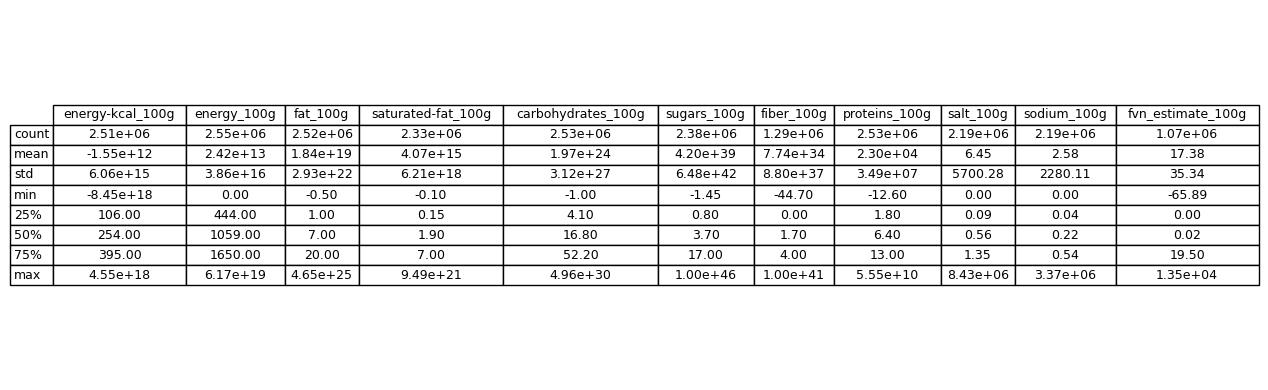

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

def format_cell(x):
    if abs(x) >= 10000:
        return f"{x:.2e}"
    return f"{x:.2f}"

cols_100g = [col for col in df.columns if col.endswith('_100g')]

desc = (df[cols_100g].describe()
          .rename(columns={'fruits-vegetables-nuts-estimate-from-ingredients_100g': 'fvn_estimate_100g'}))

table = ax.table(
    cellText=desc.applymap(format_cell).values,
    colLabels=desc.columns,
    rowLabels=desc.index,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(desc.columns))))
plt.tight_layout()
plt.savefig("describe.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
df['_nb_neg'] = (df[cols_100g] < 0).sum(axis=1)

max_neg = df['_nb_neg'].max()

from IPython.display import display

for n in range(1, max_neg + 1):
    sub = df[df['_nb_neg'] == n][cols_100g].head(5)
    if len(sub) > 0:
        print(f"Nombre de lignes avec {n} valeurs négatives : {len(df[df['_nb_neg'] == n][cols_100g])}")
        display(sub)
        print()

Nombre de lignes avec 1 valeurs négatives : 387


,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g
2237,340.0,1444.0,0.49,0.09,82.0,53.0,NaN,2.00,0.850,0.3400,-0.010887
21489,385.0,1626.0,6.50,0.80,67.0,4.0,7.0,11.00,1.100,0.4400,-0.100000
23108,565.0,2364.0,37.00,23.00,52.0,49.0,NaN,5.70,0.240,0.0960,-0.079123
24090,483.0,2020.0,24.20,12.90,59.6,35.0,NaN,4.58,0.208,0.0833,-0.053397
56757,535.0,2238.0,30.00,17.00,60.0,55.0,2.0,4.50,0.315,0.1260,-0.023058



Nombre de lignes avec 3 valeurs négatives : 1


,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g
1935269,19.0,79.0,-0.5,-0.1,4.4,4.3,NaN,-0.59,0.00004,0.000016,NaN


In [16]:
sub_1neg = df[df['_nb_neg'] == 1]
neg_counts = {col: (sub_1neg[col] < 0).sum() for col in cols_100g if (sub_1neg[col] < 0).any()}
for col, count in sorted(neg_counts.items(), key=lambda x: -x[1]):
    print(f"{col} : {count}")


fruits-vegetables-nuts-estimate-from-ingredients_100g : 380
fiber_100g : 2
proteins_100g : 2
energy-kcal_100g : 1
carbohydrates_100g : 1
sugars_100g : 1


In [17]:
df[df['energy-kcal_100g'] < 0][['energy-kcal_100g', 'energy_100g']]

,energy-kcal_100g,energy_100g
789917,-8.446744e+18,1.000000e+09


In [18]:
for col in cols_100g:
    df[col] = df[col].where(df[col] >= 0, other=np.nan)

print(f"Valeurs négatives remplacées par NaN dans {len(cols_100g)} colonnes numériques.")


Valeurs négatives remplacées par NaN dans 11 colonnes numériques.


In [19]:
mask_fat = df['saturated-fat_100g'] > df['fat_100g']
df.loc[mask_fat, ['saturated-fat_100g', 'fat_100g']] = np.nan

mask_salt = df['sodium_100g'] > df['salt_100g']
df.loc[mask_salt, ['sodium_100g', 'salt_100g']] = np.nan

print(f"Valeurs corrigées (graisses) : {mask_fat.sum():,}")
print(f"Valeurs corrigées (sel/sodium) : {mask_salt.sum():}")

Valeurs corrigées (graisses) : 1,603
Valeurs corrigées (sel/sodium) : 20


In [20]:
df[df['energy-kcal_100g'] > 900]['energy-kcal_100g'].info()

<class 'pandas.core.series.Series'>
Index: 15626 entries, 219 to 3508334
Series name: energy-kcal_100g
Non-Null Count  Dtype  
--------------  -----  
15626 non-null  float64
dtypes: float64(1)
memory usage: 244.2 KB


In [21]:
mask_kcal = df['energy-kcal_100g'] > 900
df.loc[mask_kcal, 'energy-kcal_100g'] = np.nan

mask_kj = df['energy_100g'] > 3700
df.loc[mask_kj, 'energy_100g'] = np.nan

print(f"Valeurs corrigées (kcal) : {mask_kcal.sum():,}")
print(f"Valeurs corrigées (kj) : {mask_kj.sum():,}")
print(f"Lignes restantes : {len(df):,}")

Valeurs corrigées (kcal) : 15,626
Valeurs corrigées (kj) : 23,456
Lignes restantes : 3,508,813


In [22]:
cols_0_100 = [col for col in cols_100g if col not in ('energy-kcal_100g', 'energy_100g', 'nutrition-score-fr_100g')]

for col in cols_0_100:
    df[col] = df[col].where(df[col] <= 100, other=np.nan)

In [23]:
df = df.drop(columns=['_nb_neg'])
df.describe()

,serving_quantity,additives_n,nutriscore_score,nova_group,product_quantity,unique_scans_n,completeness,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g
count,1.142547e+06,1.077193e+06,1.100050e+06,945066.000000,1.188343e+06,1.141156e+06,3.508573e+06,2.490028e+06,2.525375e+06,2.515365e+06,2.332459e+06,2.514024e+06,2.377370e+06,1.292127e+06,2.525086e+06,2.190744e+06,2.191485e+06,1.072368e+06
mean,3.579567e+06,1.860844e+00,1.103475e+01,3.362461,2.635118e+14,3.211776e+00,4.293687e-01,2.665186e+02,1.104784e+03,1.311268e+01,5.020962e+00,2.805236e+01,1.280905e+01,3.435673e+00,9.533760e+00,1.315546e+00,5.467563e-01,1.707602e+01
std,3.524151e+09,2.773118e+00,1.028474e+01,1.015011,2.863414e+17,1.341930e+01,2.128496e-01,1.847200e+02,7.587288e+02,1.669282e+01,7.771388e+00,2.725579e+01,1.889026e+01,6.101666e+00,1.181916e+01,4.304347e+00,2.074381e+00,2.975752e+01
min,0.000000e+00,0.000000e+00,-1.800000e+01,1.000000,0.000000e+00,1.000000e+00,5.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.000000e+01,0.000000e+00,2.000000e+00,3.000000,1.000000e+02,1.000000e+00,2.750000e-01,1.051625e+02,4.380000e+02,1.000000e+00,1.430000e-01,4.100000e+00,8.000000e-01,0.000000e+00,1.800000e+00,8.750000e-02,3.500000e-02,0.000000e+00
50%,8.000000e+01,1.000000e+00,1.100000e+01,4.000000,2.500000e+02,1.000000e+00,3.750000e-01,2.520000e+02,1.046000e+03,7.000000e+00,1.900000e+00,1.650000e+01,3.700000e+00,1.700000e+00,6.400000e+00,5.590000e-01,2.240000e-01,1.739502e-02
75%,1.210000e+02,3.000000e+00,1.900000e+01,4.000000,4.720000e+02,2.000000e+00,5.750000e-01,3.930000e+02,1.640000e+03,2.000000e+01,6.944444e+00,5.200000e+01,1.700000e+01,4.000000e+00,1.300000e+01,1.350000e+00,5.400000e-01,1.907964e+01
max,3.760276e+12,3.190000e+02,5.500000e+01,4.000000,3.121424e+20,3.191000e+03,1.100000e+00,9.000000e+02,3.700000e+03,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02


In [24]:
df.to_csv("/kaggle/working/df_cleaned.csv", sep="\t", index=False)

<Axes: >

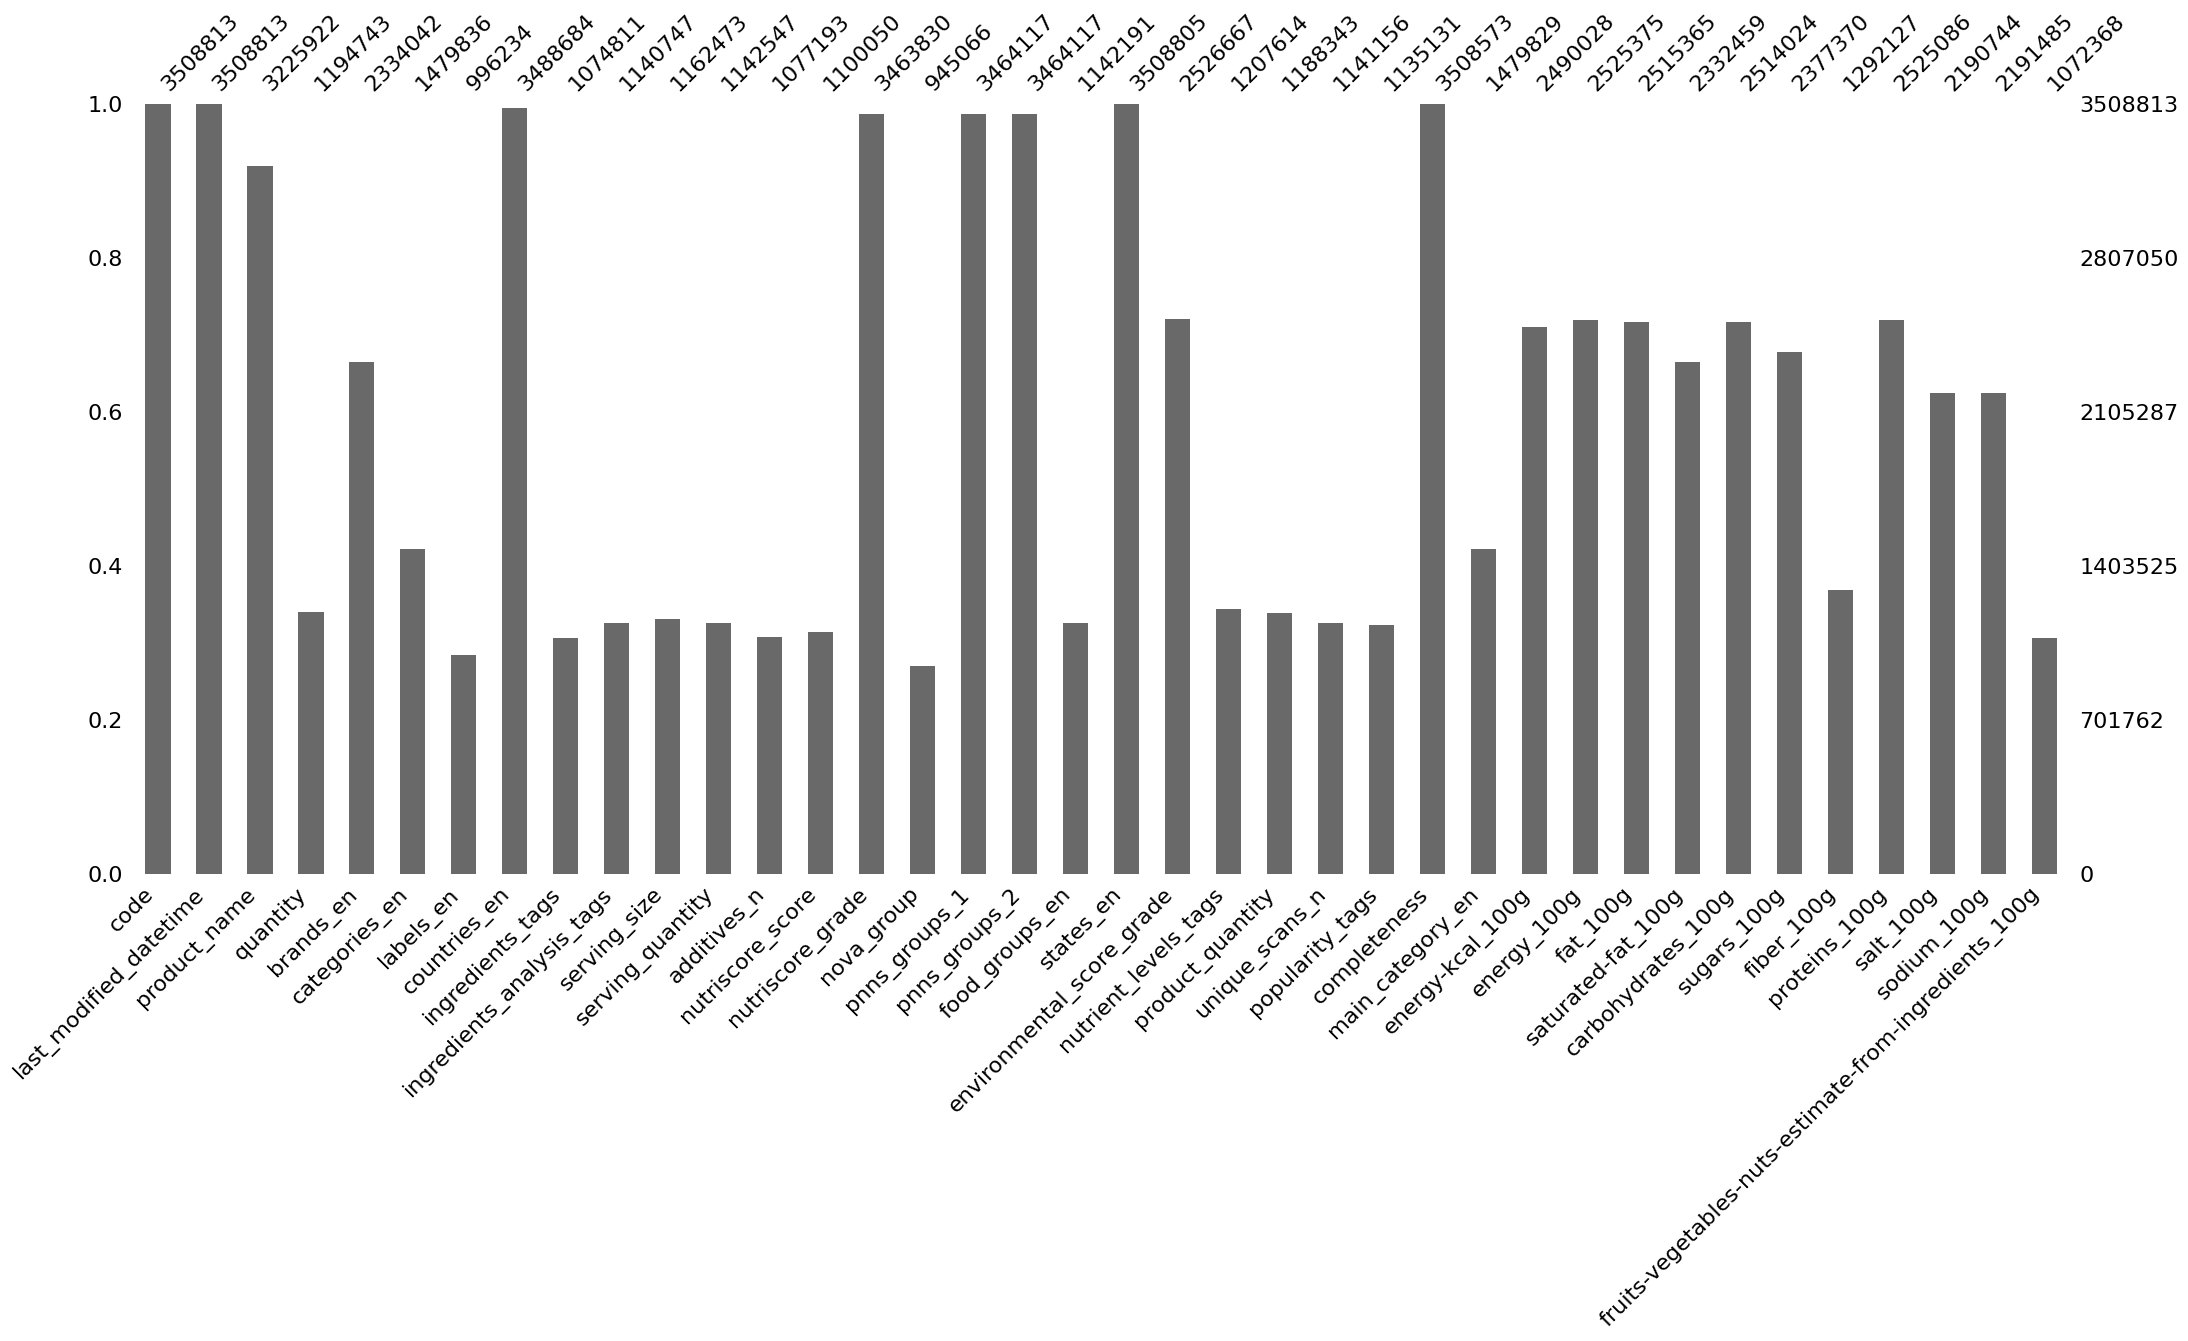

In [25]:
msno.bar(df)

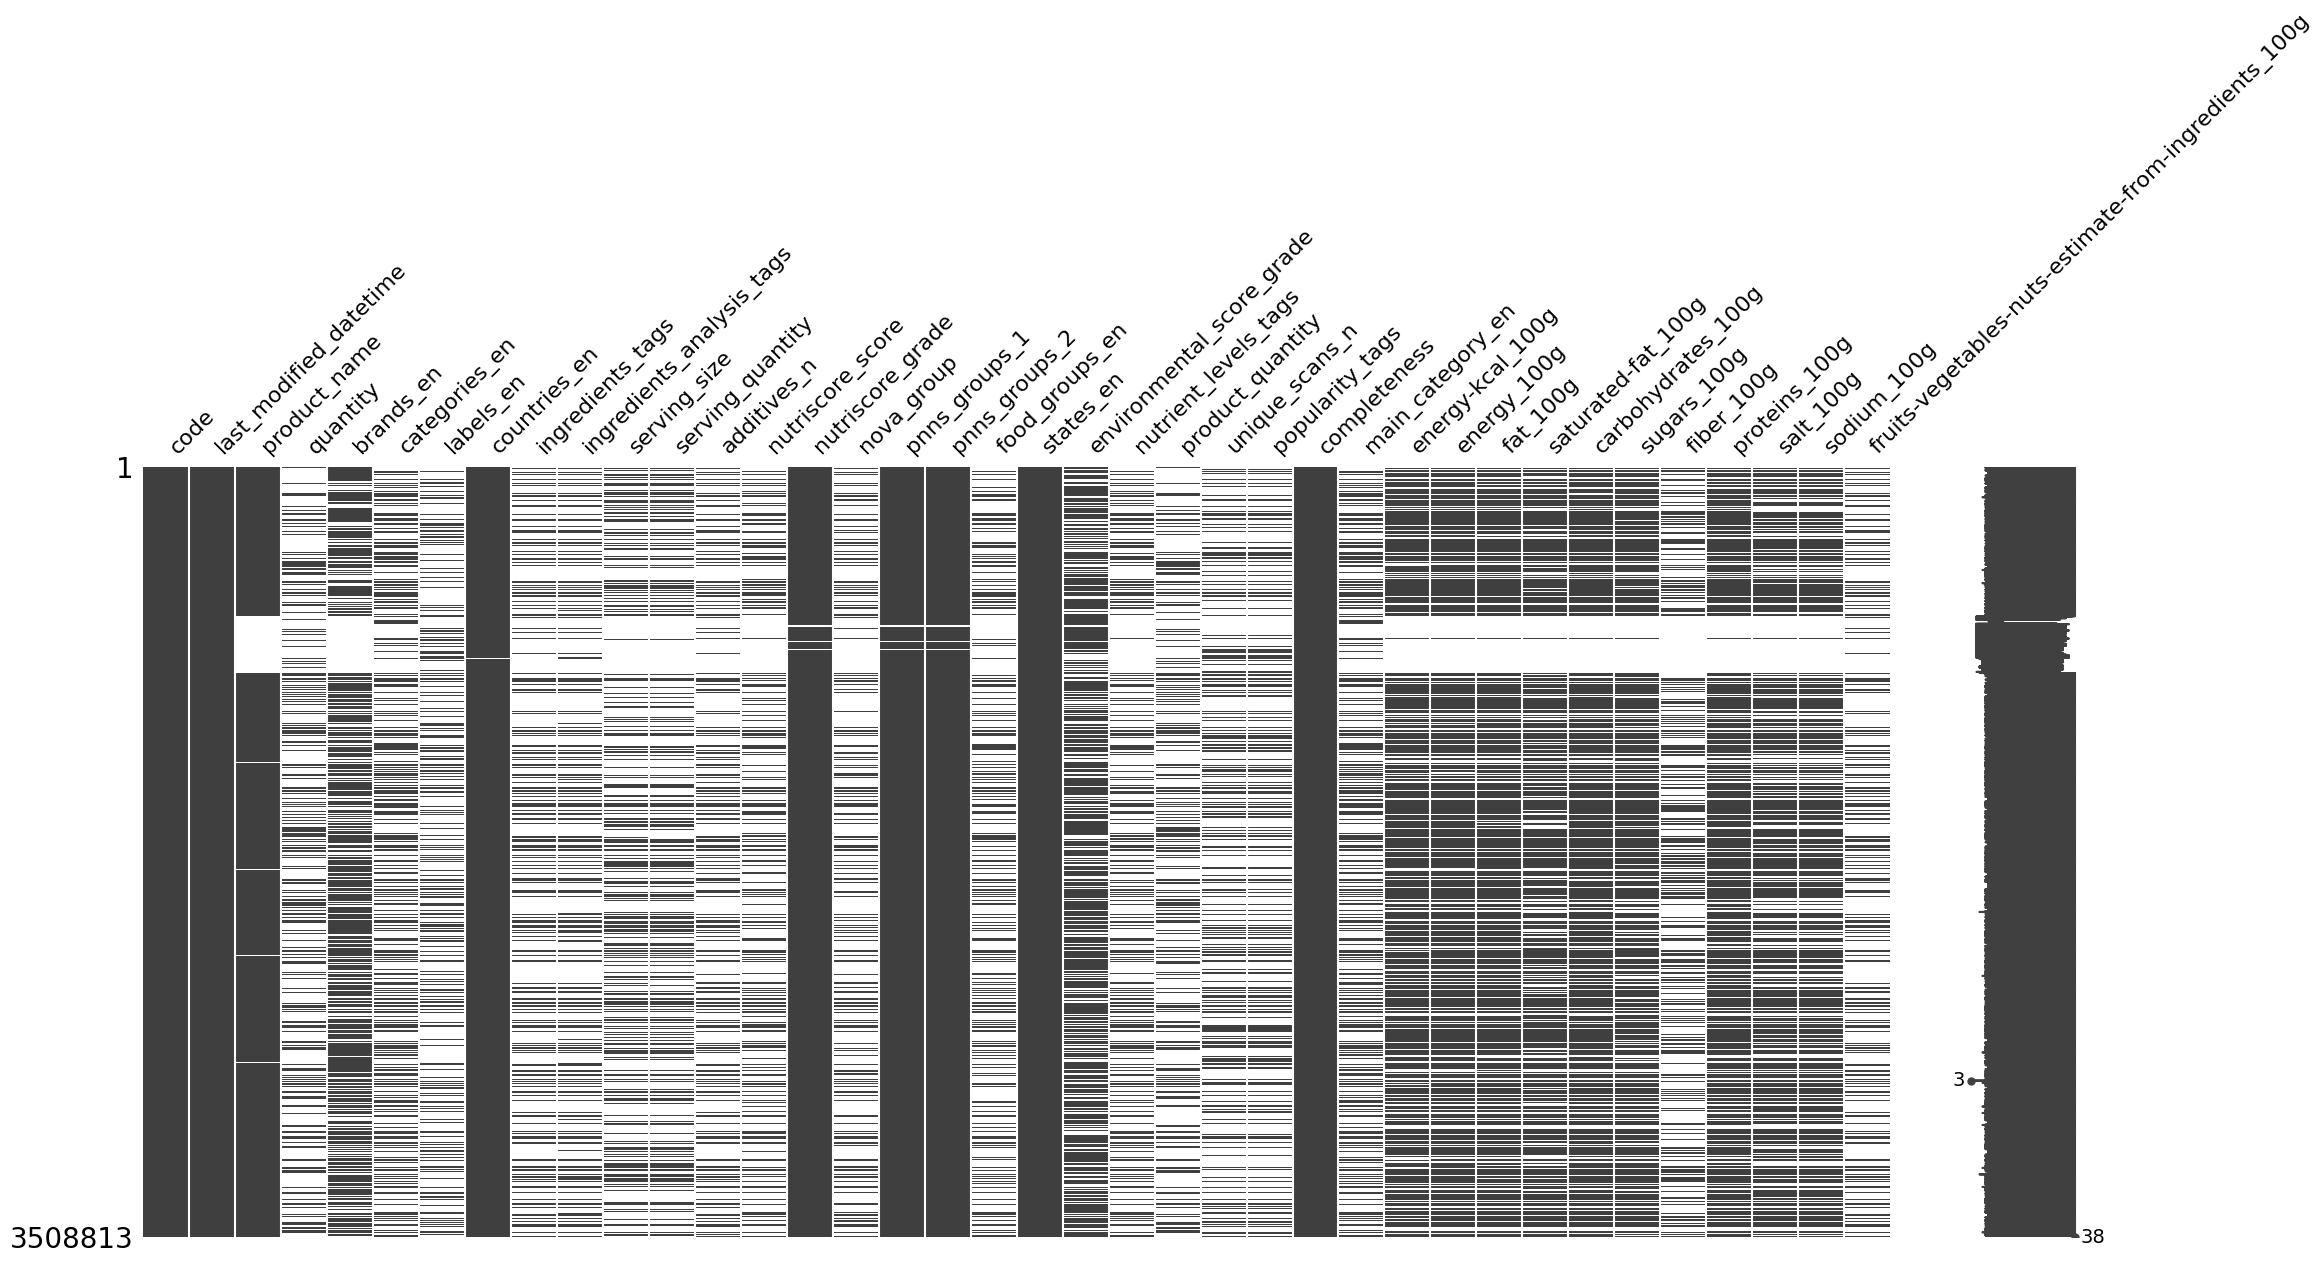

In [26]:
msno.matrix(df)
plt.savefig("2.png", dpi=150, bbox_inches='tight')
plt.show()

In [27]:
missing_pct = df.isnull().sum().sum() / df.size * 100
print(f"Données manquantes : {missing_pct:.2f}%")

Données manquantes : 41.02%


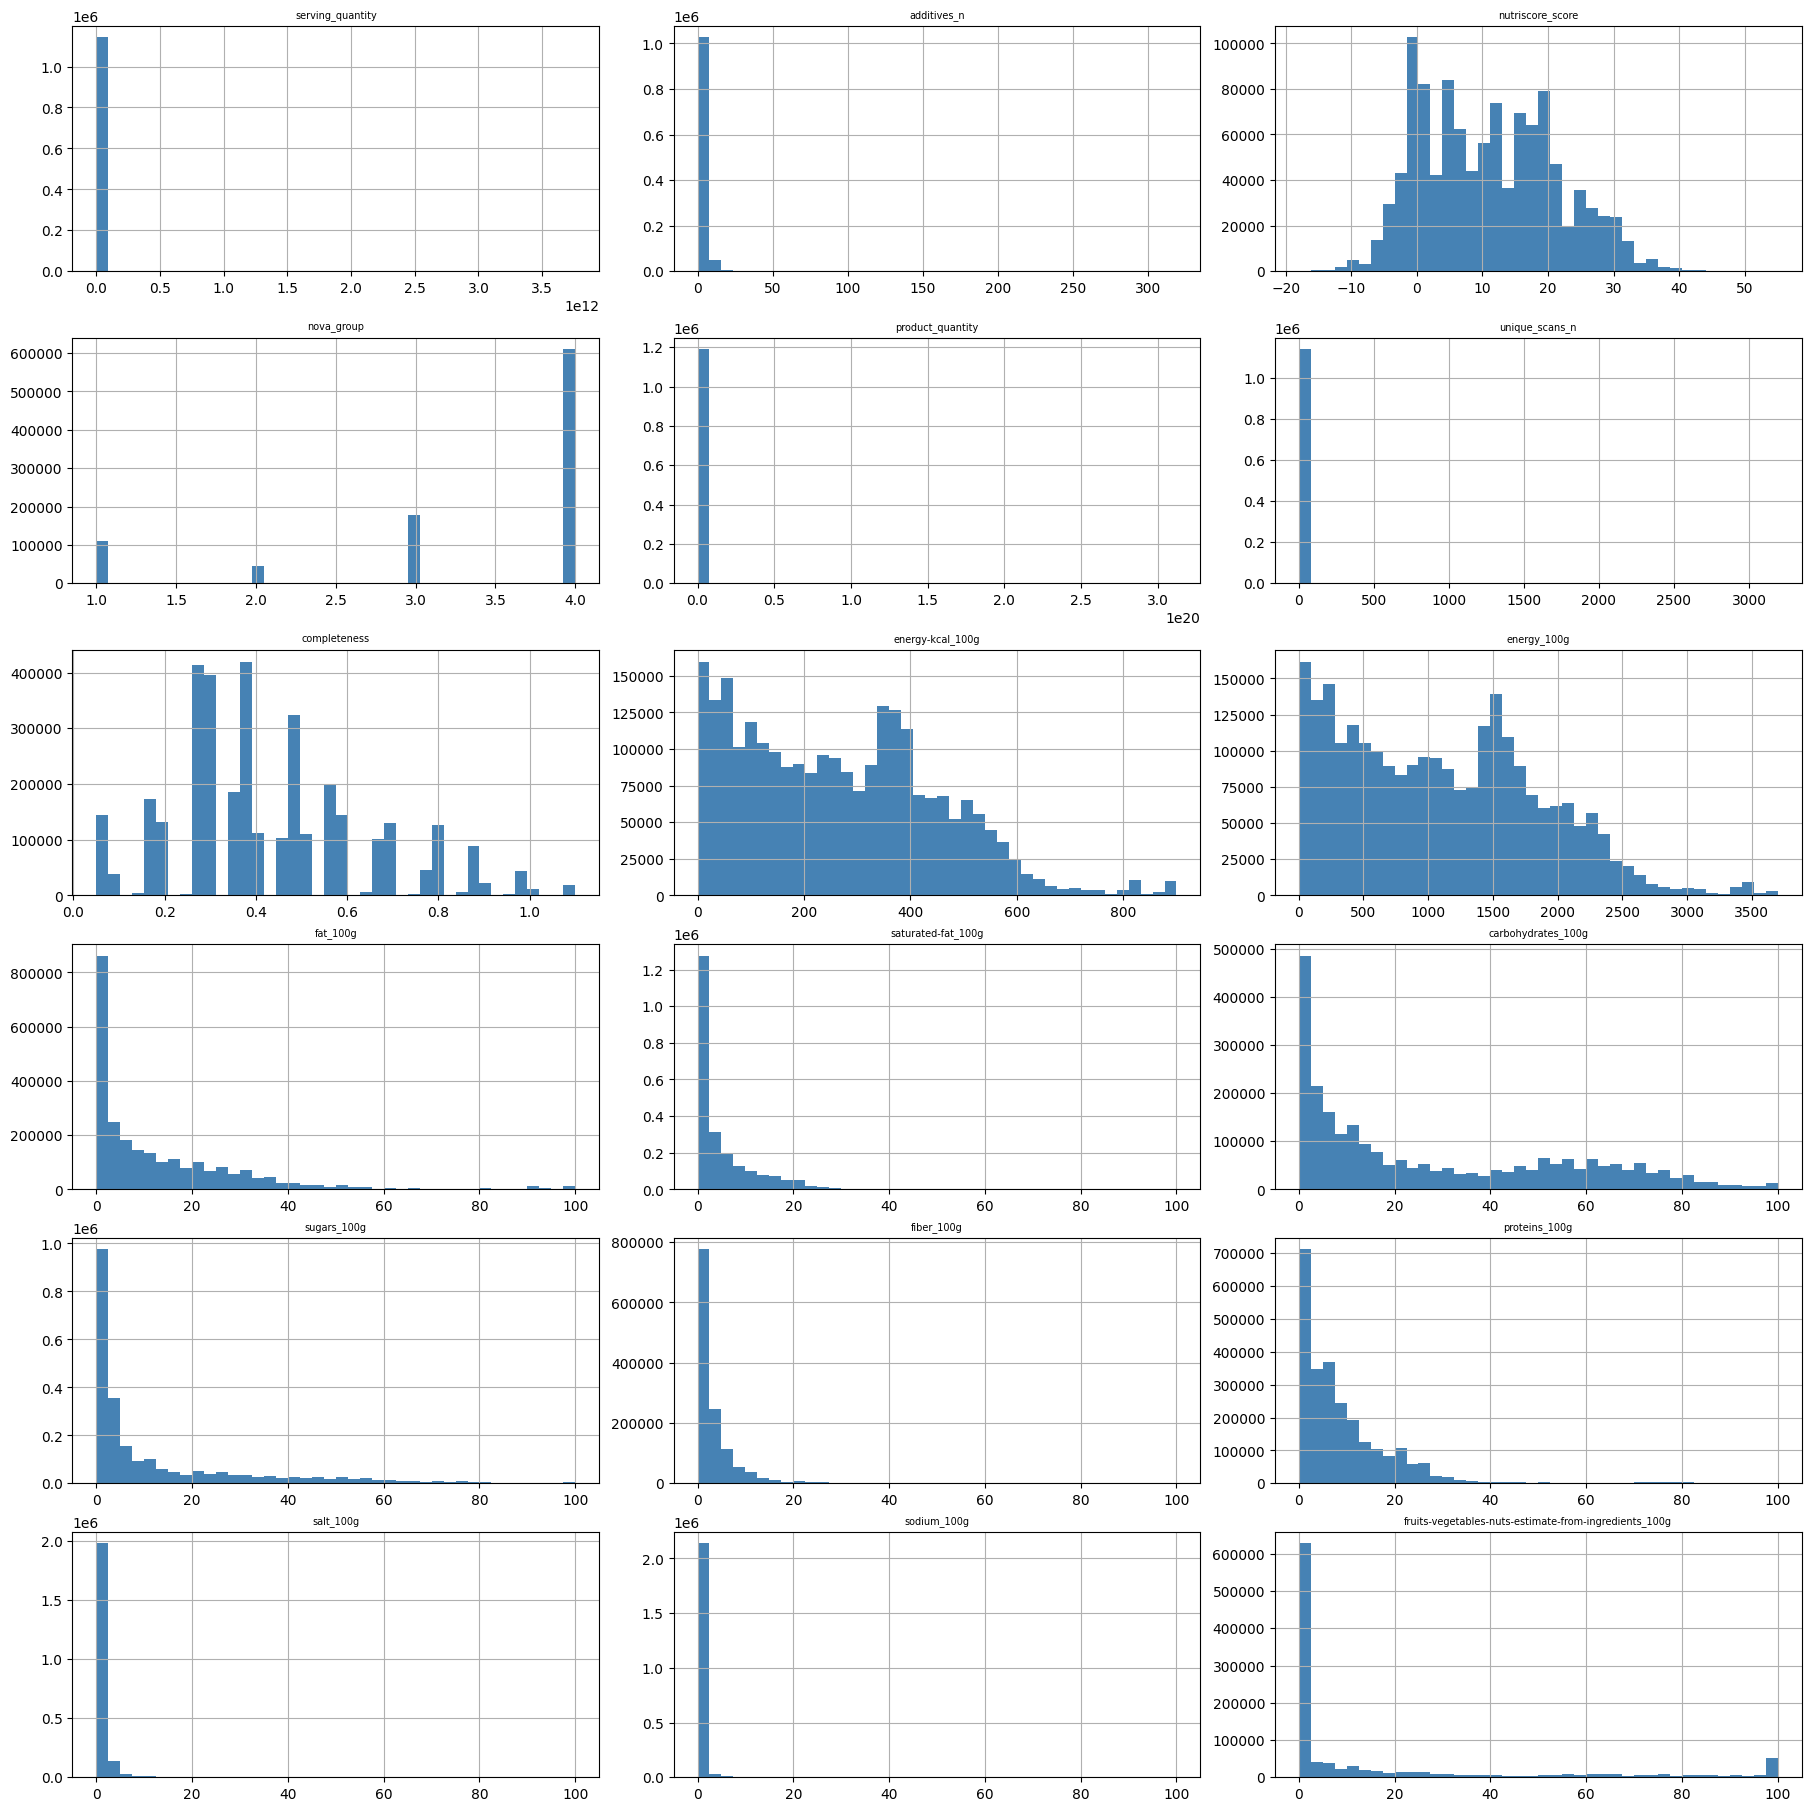

In [28]:
num_cols = df.select_dtypes(include='number').columns
fig, axes = plt.subplots(math.ceil(len(num_cols)/3), 3,
                         figsize=(18, math.ceil(len(num_cols)/3)*3),
                         constrained_layout=True)
for ax, col in zip(axes.flatten(), num_cols):
    df[col].dropna().hist(ax=ax, bins=40, color='steelblue')
    ax.set_title(col, fontsize=7)
[ax.set_visible(False) for ax in axes.flatten()[len(num_cols):]]
plt.show()

In [29]:
cols = ["nutriscore_score", "nova_group"]
df_clean_new = df[cols].dropna().copy()

df_clean_new["nova_group"] = df_clean_new["nova_group"].astype(int)
df_clean_new = df_clean_new[df_clean_new["nova_group"].isin([1, 2, 3, 4])]

print(f"Lignes utilisées : {len(df_clean_new):,}")
print(f"\nDistribution des groupes NOVA :")
print(df_clean_new["nova_group"].value_counts().sort_index())

Lignes utilisées : 709,544

Distribution des groupes NOVA :
nova_group
1     90572
2     25123
3    155205
4    438644
Name: count, dtype: int64


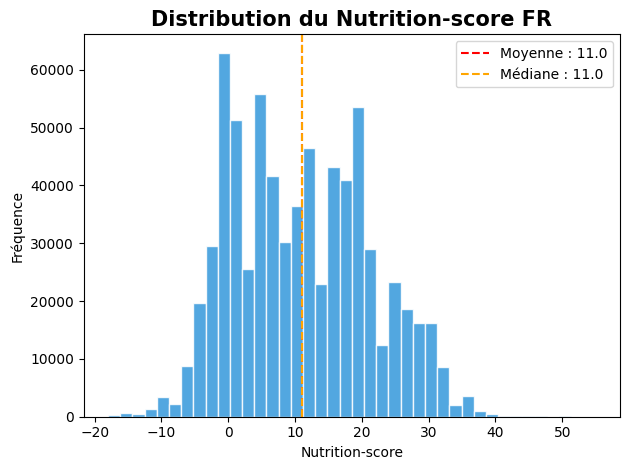

In [30]:
# Histogramme global
plt.hist(
    df_clean_new["nutriscore_score"],
    bins=40, color="#3498db", edgecolor="white", alpha=0.85
)
plt.title("Distribution du Nutrition-score FR", fontsize=15, fontweight="bold")
plt.axvline(df_clean_new["nutriscore_score"].mean(), color="red", linestyle="--", label=f"Moyenne : {df_clean_new['nutriscore_score'].mean():.1f}")
plt.axvline(df_clean_new["nutriscore_score"].median(), color="orange", linestyle="--", label=f"Médiane : {df_clean_new['nutriscore_score'].median():.1f}")
plt.xlabel("Nutrition-score")
plt.ylabel("Fréquence")
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
print("Statistiques descriptives du nutrition-score par groupe NOVA")
desc = df_clean_new.groupby("nova_group")["nutriscore_score"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)
print(desc)

Statistiques descriptives du nutrition-score par groupe NOVA
             count   mean  median   std   min   max
nova_group                                         
1            90572   0.06    -1.0  6.43 -18.0  50.0
2            25123  10.04     6.0  9.79 -12.0  42.0
3           155205  10.09    10.0  9.19 -16.0  55.0
4           438644  13.65    13.0  9.70 -17.0  55.0


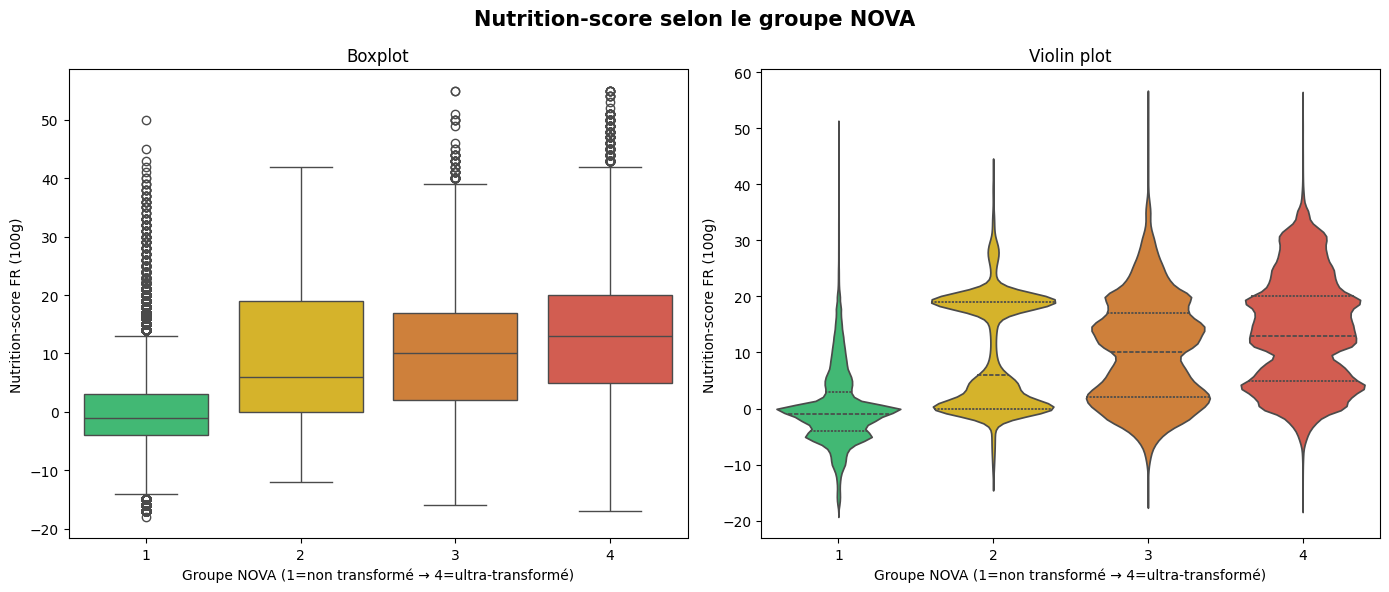

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Nutrition-score selon le groupe NOVA", fontsize=15, fontweight="bold")

palette = {1: "#2ecc71", 2: "#f1c40f", 3: "#e67e22", 4: "#e74c3c"}

# Boxplot
sns.boxplot(
    data=df_clean_new, x="nova_group", y="nutriscore_score",
    hue="nova_group", palette=palette, legend=False, ax=axes[0]
)
axes[0].set_title("Boxplot")
axes[0].set_xlabel("Groupe NOVA (1=non transformé → 4=ultra-transformé)")
axes[0].set_ylabel("Nutrition-score FR (100g)")

# Violin plot
sns.violinplot(
    data=df_clean_new, x="nova_group", y="nutriscore_score",
    hue="nova_group", palette=palette, inner="quartile", legend=False, ax=axes[1]
)
axes[1].set_title("Violin plot")
axes[1].set_xlabel("Groupe NOVA (1=non transformé → 4=ultra-transformé)")
axes[1].set_ylabel("Nutrition-score FR (100g)")

plt.tight_layout()
plt.show()

In [33]:
print("ANOVA")
groups = [
    df_clean_new[df_clean_new["nova_group"] == g]["nutriscore_score"].values
    for g in [1, 2, 3, 4]
]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic : {f_stat:.2f}")
print(f"p-value     : {p_value:.4e}")
if p_value < 0.05:
    print("→ Différence significative entre les groupes NOVA (p < 0.05)")
else:
    print("→ Pas de différence significative détectée")

# Eta-squared
grand_mean = df_clean_new["nutriscore_score"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = sum((df_clean_new["nutriscore_score"] - grand_mean) ** 2)
eta_squared = ss_between / ss_total
print(f"Eta² (taille d'effet) : {eta_squared:.3f}")
print("  Interprétation : 0.01=petit, 0.06=moyen, 0.14=grand")

ANOVA
F-statistic : 54954.15
p-value     : 0.0000e+00
→ Différence significative entre les groupes NOVA (p < 0.05)
Eta² (taille d'effet) : 0.189
  Interprétation : 0.01=petit, 0.06=moyen, 0.14=grand


In [34]:
print("Test post-hoc de Tukey (comparaisons par paires)")
tukey = pairwise_tukeyhsd(
    endog=df_clean_new["nutriscore_score"],
    groups=df_clean_new["nova_group"],
    alpha=0.05
)
print(tukey)

Test post-hoc de Tukey (comparaisons par paires)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   9.9852    0.0   9.816 10.1544   True
     1      3  10.0367    0.0  9.9374 10.1359   True
     1      4  13.5898    0.0 13.5032 13.6764   True
     2      3   0.0515 0.8453 -0.1099  0.2129  False
     2      4   3.6046    0.0  3.4507  3.7586   True
     3      4   3.5531    0.0  3.4831  3.6232   True
----------------------------------------------------


In [35]:
print("Corrélation de Spearman")
rho, p_spearman = stats.spearmanr(
    df_clean_new["nova_group"], df_clean_new["nutriscore_score"]
)
print(f"ρ de Spearman : {rho:.3f}")
print(f"p-value       : {p_spearman:.4e}")
print("Interprétation : ρ > 0 → plus le groupe NOVA est élevé, plus le score est mauvais")

Corrélation de Spearman
ρ de Spearman : 0.389
p-value       : 0.0000e+00
Interprétation : ρ > 0 → plus le groupe NOVA est élevé, plus le score est mauvais


In [36]:
print("Régression ordinale")
sample = df_clean_new.sample(min(len(df_clean_new), 20_000), random_state=42).copy()
sample["nova_group"] = sample["nova_group"].astype("category")

model = OrderedModel(
    endog=sample["nova_group"],
    exog=sample[["nutriscore_score"]],
    distr="logit"
)
result = model.fit(method="bfgs", disp=False)
print(result.summary())

print("Odds Ratios (régression ordinale logit)")
odds_ratios = np.exp(result.params)
print(odds_ratios)
print("\nInterprétation : OR > 1 → une augmentation du score augmente la probabilité d'appartenir à un groupe NOVA plus élevé (ultra-transformé)")

Régression ordinale


/usr/local/lib/python3.12/dist-packages/statsmodels/miscmodels/ordinal_model.py:205: Warning: the endog has ordered == False, risk of capturing a wrong order for the categories. ordered == True preferred.
  warnings.warn("the endog has ordered == False, "


                             OrderedModel Results                             
Dep. Variable:             nova_group   Log-Likelihood:                -18640.
Model:                   OrderedModel   AIC:                         3.729e+04
Method:            Maximum Likelihood   BIC:                         3.732e+04
Date:                Fri, 17 Apr 2026                                         
Time:                        00:49:09                                         
No. Observations:               20000                                         
Df Residuals:                   19996                                         
Df Model:                           1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
nutriscore_score     0.0908      0.002     53.517      0.000       0.087       0.094
1/2                 -1.1788      0

In [37]:
df_nutri = df[cols_100g + ['nutriscore_score', 'nutriscore_grade', 'product_name', 'categories_en']]

missing_counts = df_nutri.isnull().sum()
missing_pct = (missing_counts / len(df_nutri) * 100).round(2)

missing_df = pd.DataFrame({
    'Colonne': missing_counts.index,
    'Valeurs manquantes': missing_counts.values,
    'Pourcentage (%)': missing_pct.values
}).sort_values('Pourcentage (%)', ascending=False)

print(missing_df.to_string(index=False))


                                              Colonne  Valeurs manquantes  Pourcentage (%)
fruits-vegetables-nuts-estimate-from-ingredients_100g             2436445            69.44
                                     nutriscore_score             2408763            68.65
                                           fiber_100g             2216686            63.17
                                        categories_en             2028977            57.83
                                            salt_100g             1318069            37.56
                                          sodium_100g             1317328            37.54
                                   saturated-fat_100g             1176354            33.53
                                          sugars_100g             1131443            32.25
                                     energy-kcal_100g             1018785            29.04
                                   carbohydrates_100g              994789            28.35

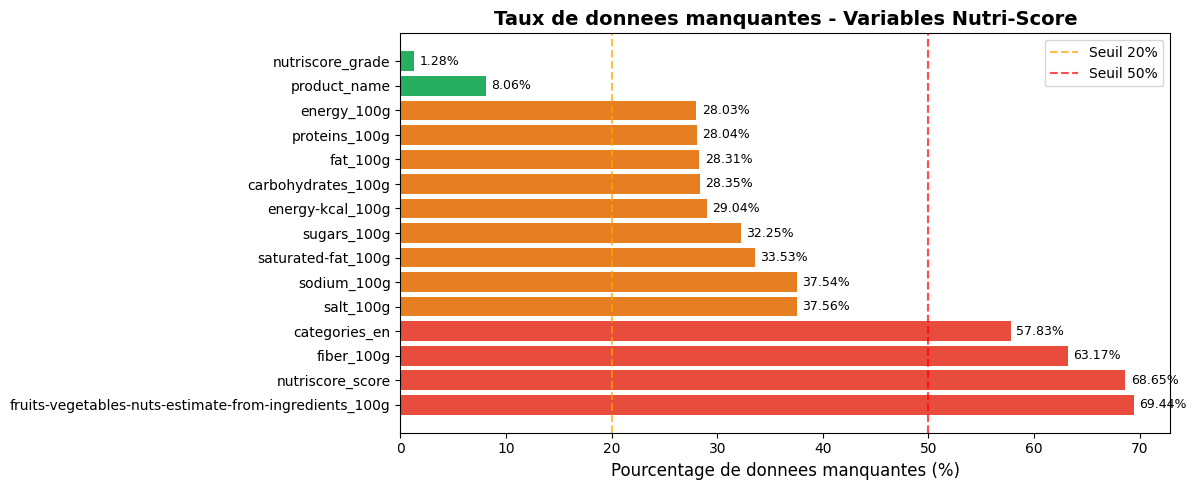

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = [
    '#e74c3c' if p > 50 else '#e67e22' if p > 20 else '#27ae60'
    for p in missing_df['Pourcentage (%)']
]

bars = ax.barh(missing_df['Colonne'], missing_df['Pourcentage (%)'], color=colors)
ax.set_xlabel("Pourcentage de donnees manquantes (%)", fontsize=12)
ax.set_title("Taux de donnees manquantes - Variables Nutri-Score", fontsize=14, fontweight='bold')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Seuil 20%')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='Seuil 50%')
ax.legend()

for bar, pct in zip(bars, missing_df['Pourcentage (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("Taux de donnees manquantes - Variables Nutri-Score.png", dpi=150, bbox_inches='tight')
plt.show()


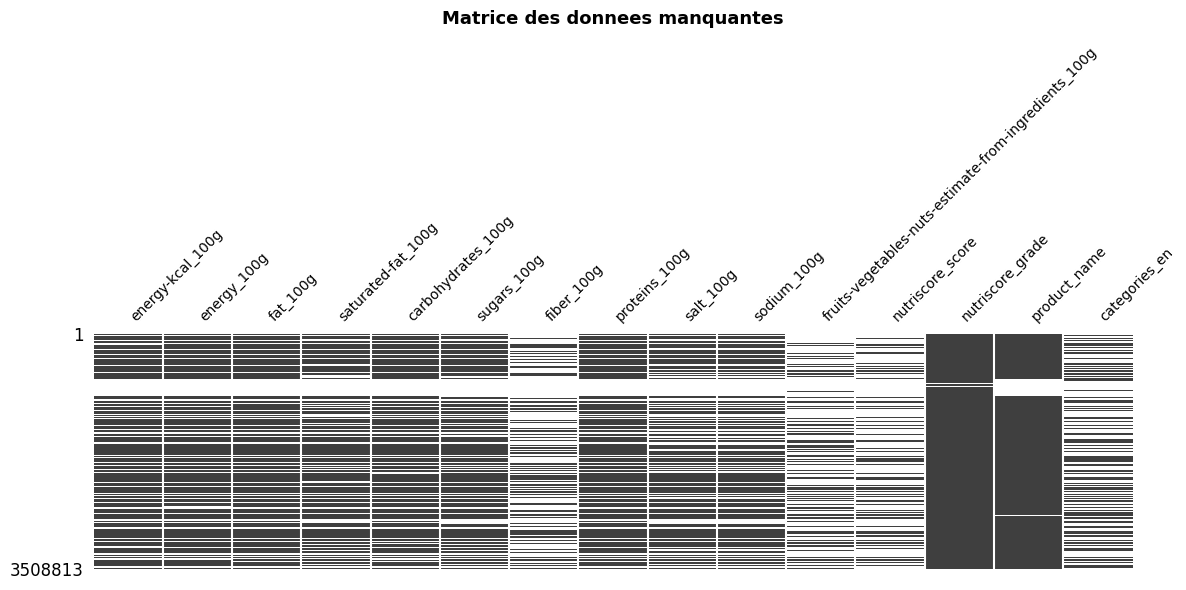

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
msno.matrix(df_nutri, ax=ax, sparkline=False, fontsize=10)
ax.set_title(f"Matrice des donnees manquantes",
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


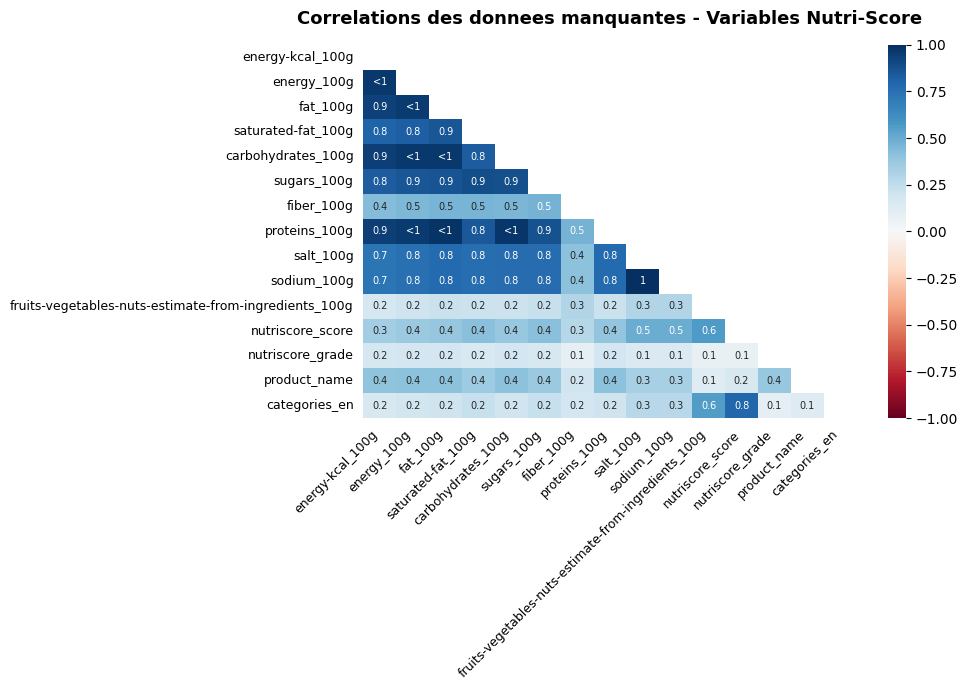

In [40]:
fig, ax = plt.subplots(figsize=(10, 7))
msno.heatmap(df_nutri, ax=ax, fontsize=9)
ax.set_title("Correlations des donnees manquantes - Variables Nutri-Score",
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("Correlations des donnees manquantes - Variables Nutri-Score.png", dpi=150, bbox_inches='tight')
plt.show()

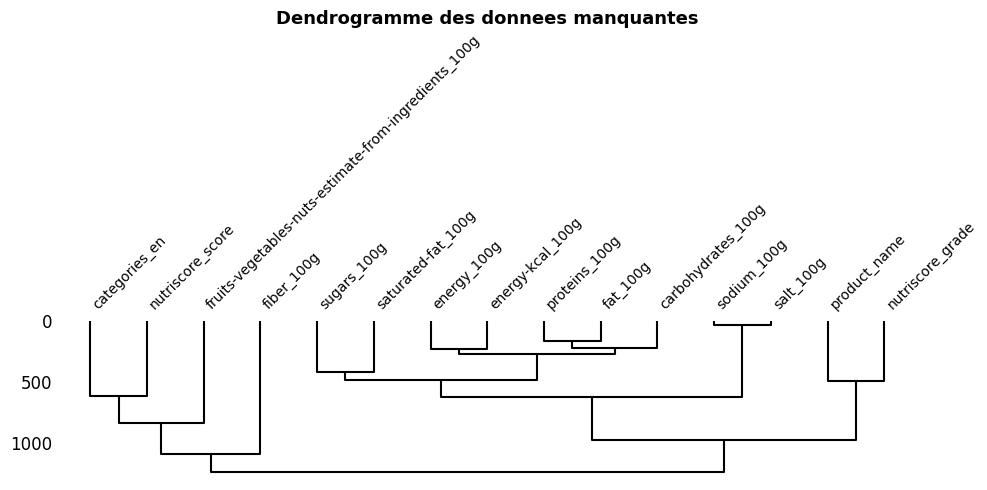

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
msno.dendrogram(df_nutri, ax=ax, fontsize=10)
ax.set_title("Dendrogramme des donnees manquantes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Dendrogramme des donnees manquantes.png", dpi=150, bbox_inches='tight')
plt.show()

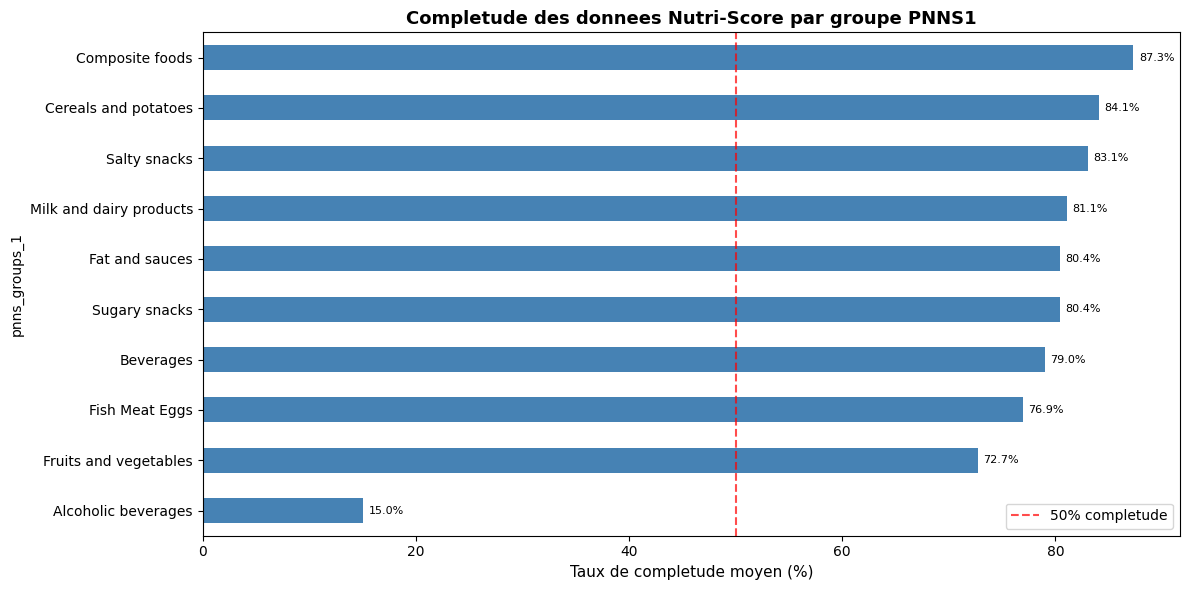

In [42]:
if 'pnns_groups_1' in df.columns:
    df_pnns = df[['pnns_groups_1'] + cols_100g].copy()
    df_pnns = df_pnns[
        df_pnns['pnns_groups_1'].notna() &
        (df_pnns['pnns_groups_1'] != 'unknown')
    ]

    completeness = (
        df_pnns.groupby('pnns_groups_1')[cols_100g]
        .apply(lambda x: x.notna().mean().mean() * 100)
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    completeness.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel("Taux de completude moyen (%)", fontsize=11)
    ax.set_title("Completude des donnees Nutri-Score par groupe PNNS1",
                 fontsize=13, fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% completude')
    ax.legend()
    for i, v in enumerate(completeness.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig("Completude des donnees Nutri-Score par groupe PNNS1.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Colonne pnns_groups_1 non disponible.")


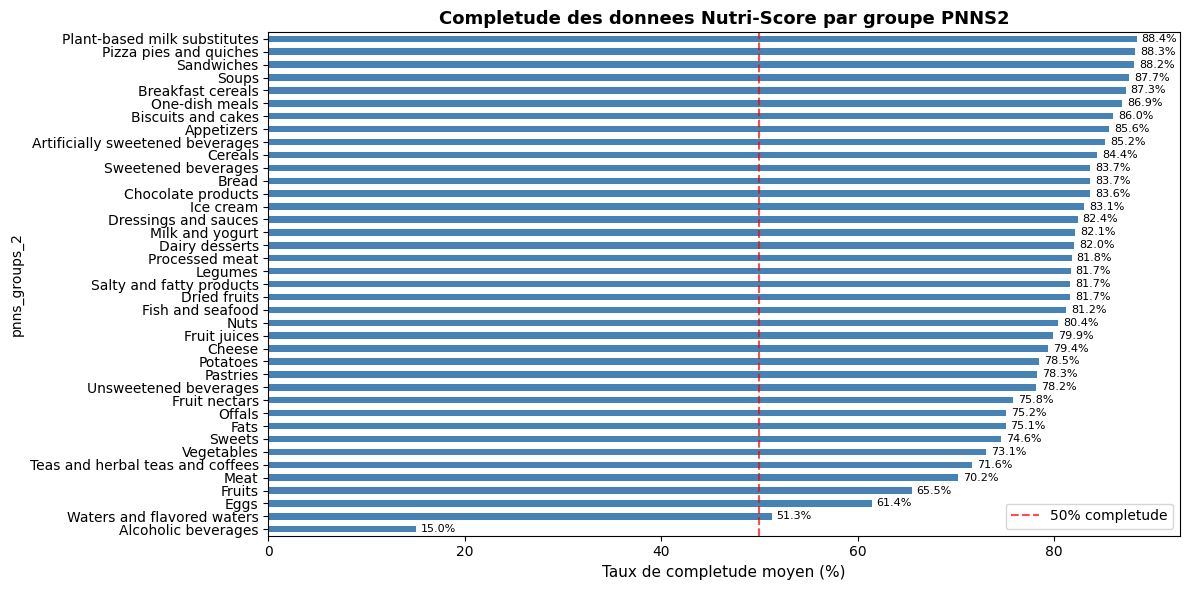

In [43]:
if 'pnns_groups_2' in df.columns:
    df_pnns = df[['pnns_groups_2'] + cols_100g].copy()
    df_pnns = df_pnns[
        df_pnns['pnns_groups_2'].notna() &
        (df_pnns['pnns_groups_2'] != 'unknown')
    ]

    completeness = (
        df_pnns.groupby('pnns_groups_2')[cols_100g]
        .apply(lambda x: x.notna().mean().mean() * 100)
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    completeness.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel("Taux de completude moyen (%)", fontsize=11)
    ax.set_title("Completude des donnees Nutri-Score par groupe PNNS2",
                 fontsize=13, fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% completude')
    ax.legend()
    for i, v in enumerate(completeness.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig("Completude des donnees Nutri-Score par groupe PNNS2.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Colonne pnns_groups_1 non disponible.")


In [44]:
cols_nutriscore = [
    'product_name',
    'energy_100g',                                          # e : énergie (kJ)
    'saturated-fat_100g',                                   # g : graisses saturées
    'sugars_100g',                                          # s : sucres
    'sodium_100g',                                          # n : sodium
    'fruits-vegetables-nuts-estimate-from-ingredients_100g',# f : fruits/légumes (%)
    'fiber_100g',                                           # phi : fibres
    'proteins_100g'                                         # p : protéines
]

df_nutri = df[cols_nutriscore].copy()

df_nutri.columns = ['nom', 'energie', 'graisses', 'sucres', 'sodium', 
                    'fruits', 'fibres', 'proteines']
df_nutri = df_nutri.dropna()
print(df_nutri.shape)

(577443, 8)


In [45]:
def Ene(e):
    if e <= 335:    return 0
    elif e <= 670:  return 1
    elif e <= 1005: return 2
    elif e <= 1340: return 3
    elif e <= 1675: return 4
    elif e <= 2010: return 5
    elif e <= 2345: return 6
    elif e <= 2680: return 7
    elif e <= 3015: return 8
    elif e <= 3350: return 9
    else:           return 10

def Gra(g):
    if g <= 1:  return 0
    elif g <= 2:  return 1
    elif g <= 3:  return 2
    elif g <= 4:  return 3
    elif g <= 5:  return 4
    elif g <= 6:  return 5
    elif g <= 7:  return 6
    elif g <= 8:  return 7
    elif g <= 9:  return 8
    elif g <= 10: return 9
    else:         return 10

def Suc(s):
    if s <= 4.5:    return 0
    elif s <= 9:    return 1
    elif s <= 13.5: return 2
    elif s <= 18:   return 3
    elif s <= 22.5: return 4
    elif s <= 27:   return 5
    elif s <= 31:   return 6
    elif s <= 36:   return 7
    elif s <= 40:   return 8
    elif s <= 45:   return 9
    else:           return 10

def Sod(n):
    n = n * 1000  # conversion g -> mg
    if n <= 90:    return 0
    elif n <= 180: return 1
    elif n <= 270: return 2
    elif n <= 360: return 3
    elif n <= 450: return 4
    elif n <= 540: return 5
    elif n <= 630: return 6
    elif n <= 720: return 7
    elif n <= 810: return 8
    elif n <= 900: return 9
    else:          return 10

def A(row):
    return Ene(row['energie']) + Gra(row['graisses']) + Suc(row['sucres']) + Sod(row['sodium'])

df_nutri['A'] = df_nutri.apply(A, axis=1)

In [46]:
def Fru(f):
    if f <= 40:   return 0
    elif f <= 60: return 1
    elif f <= 80: return 2
    else:         return 5

def Fib(phi):
    if phi <= 0.9:  return 0
    elif phi <= 1.9: return 1
    elif phi <= 2.8: return 2
    elif phi <= 3.7: return 3
    elif phi <= 4.7: return 4
    else:            return 5

def Pro(p):
    if p <= 1.6:  return 0
    elif p <= 3.2: return 1
    elif p <= 4.8: return 2
    elif p <= 6.4: return 3
    elif p <= 8.0: return 4
    else:          return 5

def C(row):
    return Fru(row['fruits']) + Fib(row['fibres']) + Pro(row['proteines'])

df_nutri['C'] = df_nutri.apply(C, axis=1)

In [47]:
def Score(row):
    a = row['A']
    c = row['C']
    fru = Fru(row['fruits'])
    fib = Fib(row['fibres'])
    
    if a < 11:
        return a - c
    elif fru == 5:
        return a - c
    else:
        return a - (fru + fib)

def Let(score):
    if score <= -1:   return 'A'
    elif score <= 2:  return 'B'
    elif score <= 10: return 'C'
    elif score <= 18: return 'D'
    else:             return 'E'

df_nutri['score'] = df_nutri.apply(Score, axis=1)
df_nutri['lettre'] = df_nutri['score'].apply(Let)

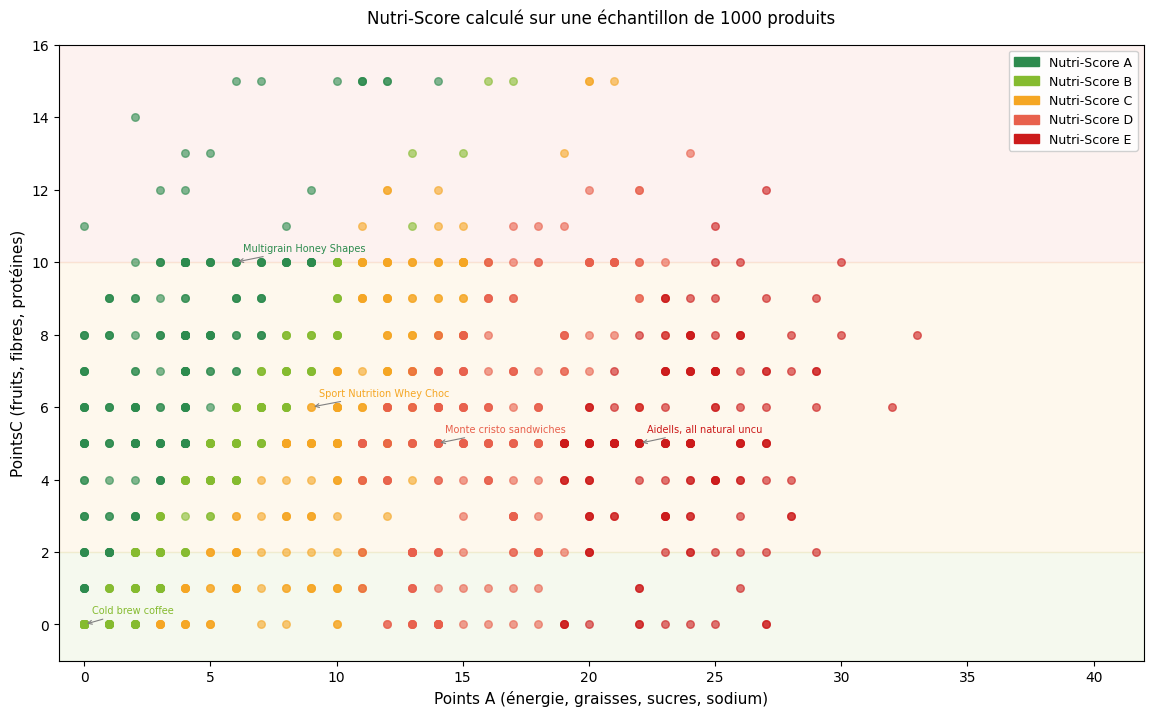

In [48]:
sample = df_nutri.sample(1000, random_state=42)

couleurs_map = {'A': '#2d8b4e', 'B': '#85bb2f', 'C': '#f5a623', 'D': '#e8604c', 'E': '#cc1a1a'}
zones = [(-15, -1, '#2d8b4e', 'A'), (-1, 2, '#85bb2f', 'B'), 
         (2, 10, '#f5a623', 'C'), (10, 18, '#e8604c', 'D'), (18, 45, '#cc1a1a', 'E')]

fig, ax = plt.subplots(figsize=(14, 8))

for y_min, y_max, couleur, lettre in zones:
    ax.axhspan(y_min, y_max, alpha=0.08, color=couleur)

for lettre, groupe in sample.groupby('lettre'):
    ax.scatter(groupe['A'], groupe['C'],
               c=couleurs_map[lettre], alpha=0.6, s=30, zorder=3)

for lettre in ['A', 'B', 'C', 'D', 'E']:
    sous = sample[sample['lettre'] == lettre].dropna(subset=['nom'])
    if len(sous) > 0:
        row = sous.iloc[0]
        nom = str(row['nom'])[:25]
        ax.annotate(nom,
                    xy=(row['A'], row['C']),
                    xytext=(row['A'] + 0.3, row['C'] + 0.3),
                    fontsize=7,
                    color=couleurs_map[lettre],
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# Mise en forme
ax.set_xlabel('Points A (énergie, graisses, sucres, sodium)', fontsize=11)
ax.set_ylabel('PointsC (fruits, fibres, protéines)', fontsize=11)
ax.set_title('Nutri-Score calculé sur une échantillon de 1000 produits',
             fontsize=12, pad=15)

# Légende
patches = [mpatches.Patch(color=c, label=f'Nutri-Score {l}') 
           for l, c in couleurs_map.items()]
ax.legend(handles=patches, loc='upper right', framealpha=0.9, fontsize=9)

ax.set_xlim(-1, 42)
ax.set_ylim(-1, 16)
plt.savefig('nutriscore_plot.png', dpi=150, bbox_inches='tight')
plt.show()